In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/train.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Preprocessing Decisions from EDA

1. Age contains missing values → median imputation
2. Cabin has excessive missing values → drop column
3. Fare is right-skewed → transformation required
4. Sex and Embarked need encoding
5. Family-related features may be useful

**Handling missing values**

In [4]:
df_old = df

In [5]:
# Numerical
df['Age'] = df['Age'].fillna(df['Age'].median())

In [6]:
# categorical
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


All missing values have been successfully handled.

**Drop Excessively Missing Columns**

In [8]:
df.drop(['PassengerId','Cabin'],axis=1,inplace=True)

- PassengerId features are droped because they don't add value for model traning
- Cabin feature is drop because it contains neer about 70% missing values

In [9]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


**Handle Duplicates**

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

**Data Type Corrections**

In [12]:
df['Pclass'] = df['Pclass'].astype('category')

**Feature Creation**

In [13]:
df['FamilySize'] = df['Parch'] + df['SibSp'] + 1

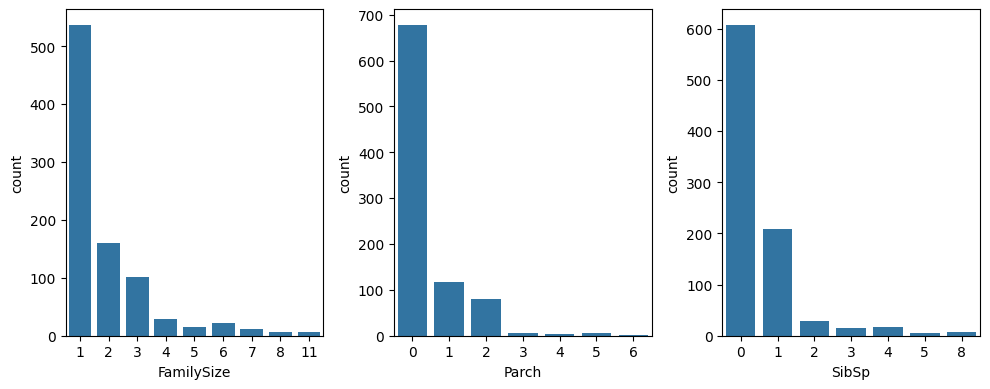

In [14]:
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
sns.countplot(data=df,x='FamilySize')

plt.subplot(1,3,2)
sns.countplot(data=df,x='Parch')

plt.subplot(1,3,3)
sns.countplot(data=df,x='SibSp')

plt.tight_layout()
plt.show()

In [15]:
df.groupby('SibSp')['Survived'].mean()

,Survived
SibSp,
0,0.345395
1,0.535885
2,0.464286
3,0.250000
4,0.166667
5,0.000000
8,0.000000


In [16]:
df.groupby('Parch')['Survived'].mean()

,Survived
Parch,
0,0.343658
1,0.550847
2,0.500000
3,0.600000
4,0.000000
5,0.200000
6,0.000000


In [17]:
df.groupby('FamilySize')['Survived'].mean()

,Survived
FamilySize,
1,0.303538
2,0.552795
3,0.578431
4,0.724138
5,0.200000
6,0.136364
7,0.333333
8,0.000000
11,0.000000


In [18]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [19]:
df.groupby('IsAlone')['Survived'].mean()

,Survived
IsAlone,
0,0.505650
1,0.303538


In [20]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\. ')

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_2128/331111622.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\. ')


In [21]:
df.groupby('Title')['Survived'].mean()

,Survived
Title,
Capt,0.000000
Col,0.500000
Countess,1.000000
Don,0.000000
Dr,0.428571
Jonkheer,0.000000
Lady,1.000000
Major,0.500000
Master,0.575000


In [22]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,Title
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Mrs
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Mrs
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Mr


**Feature Transformation**

In [23]:
df['Fare'] = np.log1p(df['Fare'])

<Axes: xlabel='Fare', ylabel='Count'>

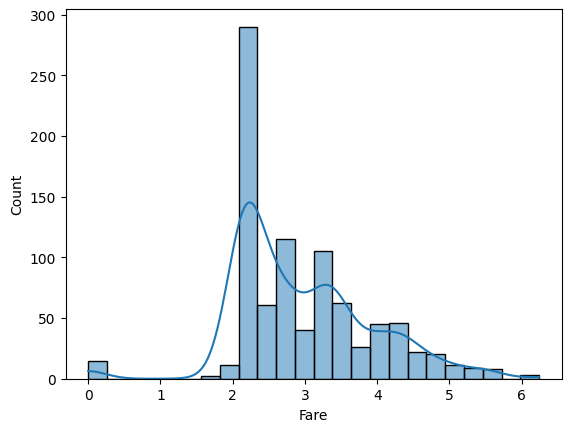

In [24]:
sns.histplot(data=df,x='Fare',kde=True)

**Binning**

In [25]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins = [0,18,35,50,100],
    labels= ['Child','Young','Adult','Senior']
)

**Lable Encoding**

In [26]:
df['Sex'] = df['Sex'].map({
    'male':0,
    'female':1
})

In [27]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,Title,AgeGroup
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,2.110213,S,2,0,Mr,Young
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,4.280593,C,2,0,Mrs,Adult
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,2.188856,S,1,1,Miss,Young
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,3.990834,S,2,0,Mrs,Young
4,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,2.202765,S,1,1,Mr,Young


**One-Hot-Encoding**

In [28]:
df = pd.get_dummies(
    df,
    columns=['Embarked'],
    drop_first=True
)

In [29]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,FamilySize,IsAlone,Title,AgeGroup,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,2.110213,2,0,Mr,Young,False,True
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,4.280593,2,0,Mrs,Adult,False,False
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,2.188856,1,1,Miss,Young,False,True
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,3.990834,2,0,Mrs,Young,False,True
4,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,2.202765,1,1,Mr,Young,False,True


Categorical variables have been successfully converted into numerical representations suitable for machine learning models.

**Outlier Treatment**

In [30]:
# IQR method
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [31]:
#Capping
df['Fare'] = np.clip(
    df['Fare'],
    lower,
    upper
)

<Axes: xlabel='Fare', ylabel='Count'>

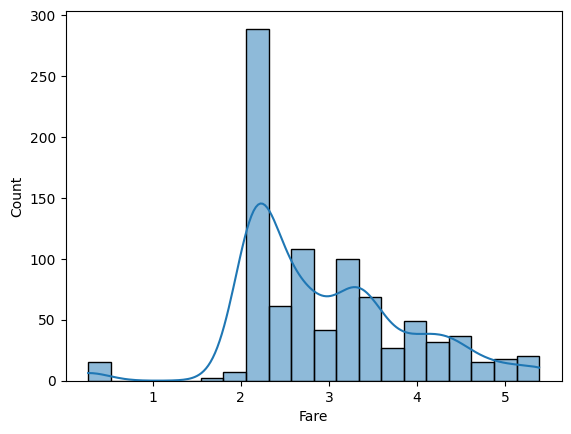

In [32]:
sns.histplot(data=df,x='Fare',kde=True)

<Axes: xlabel='Fare'>

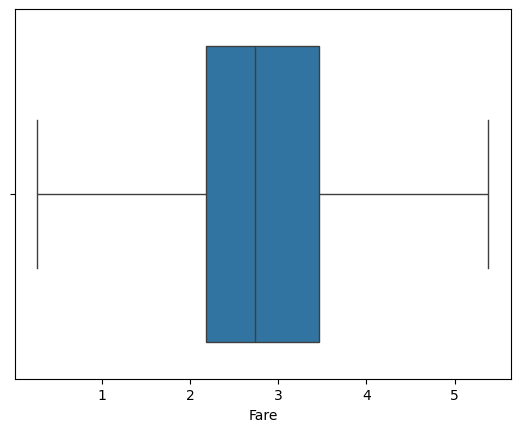

In [33]:
sns.boxplot(data=df,x='Fare')

**Scaling**

In [34]:
# Min-Max scaling
df['Age_scaled'] = (
    (df['Age'] - df['Age'].min())/
    (df['Age'].max() - df['Age'].min())
)

In [35]:
# Standardization
df['Age_standardized'] = (
    (df['Age'] - df['Age'].mean()) /
    df['Age'].std()
)

**Final Dataset Review**

In [36]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,FamilySize,IsAlone,Title,AgeGroup,Embarked_Q,Embarked_S,Age_scaled,Age_standardized
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,2.110213,2,0,Mr,Young,False,True,0.271174,-0.565419
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,4.280593,2,0,Mrs,Adult,False,False,0.472229,0.663488
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,2.188856,1,1,Miss,Young,False,True,0.321438,-0.258192
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,3.990834,2,0,Mrs,Young,False,True,0.434531,0.433068
4,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,2.202765,1,1,Mr,Young,False,True,0.434531,0.433068


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Survived          891 non-null    int64   
 1   Pclass            891 non-null    category
 2   Name              891 non-null    object  
 3   Sex               891 non-null    int64   
 4   Age               891 non-null    float64 
 5   SibSp             891 non-null    int64   
 6   Parch             891 non-null    int64   
 7   Ticket            891 non-null    object  
 8   Fare              891 non-null    float64 
 9   FamilySize        891 non-null    int64   
 10  IsAlone           891 non-null    int64   
 11  Title             891 non-null    object  
 12  AgeGroup          891 non-null    category
 13  Embarked_Q        891 non-null    bool    
 14  Embarked_S        891 non-null    bool    
 15  Age_scaled        891 non-null    float64 
 16  Age_standardized  891 non-

In [38]:
df.shape

(891, 17)

# Feature Engineering Summary

1. Missing values imputed
2. Cabin column removed
3. Fare transformed using log transformation
4. FamilySize and IsAlone features created
5. Categorical features encoded
6. Outliers capped
7. Numerical features scaled


# Feature Engineering Summary

Applied Transformations

1. Missing Value Imputation
   - Age → Median
   - Embarked → Mode

2. Duplicate Removal

3. Data Type Corrections

4. Feature Creation
   - FamilySize
   - IsAlone
   - Title

5. Feature Transformation
   - Log Transformation on Fare

6. Binning
   - AgeGroup

7. Encoding
   - Label Encoding (Sex)
   - One-Hot Encoding (Embarked)

8. Outlier Treatment
   - Fare capping

9. Scaling
   - Min-Max Scaling
   - Standardization

The dataset is now prepared for machine learning pipelines and modeling.